# Modeling And Offline Evaluation

Ноутбук фиксирует экспериментальную часть проекта как самостоятельный decision document. Задача offline-контура: по истории пользователя вернуть `top-K` товаров, которые с максимальной вероятностью попадут в будущий `addtocart` в правом временном окне.


In [12]:
from pathlib import Path
import json
import numpy as np

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.dates import date2num
from matplotlib.ticker import FuncFormatter, PercentFormatter
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['legend.frameon'] = False
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

ROOT = Path.cwd().resolve()
if not (ROOT / 'artifacts').exists():
    ROOT = ROOT.parent

with (ROOT / 'artifacts' / 'reports' / 'modeling_notebook_report.json').open(encoding='utf-8') as f:
    modeling_report = json.load(f)
with (ROOT / 'artifacts' / 'reports' / 'evaluation_summary.json').open(encoding='utf-8') as f:
    evaluation_summary = json.load(f)

eval_frame = pd.read_parquet(ROOT / 'artifacts' / 'data' / 'evaluation_frame.parquet')
eval_frame['target_count'] = eval_frame['target_items'].map(len)

MODEL_LABELS = {
    'history_baseline': 'Исторический baseline',
    'hybrid_history_item2item': 'Гибрид истории и item2item',
    'weighted_item2item': 'Взвешенный item2item',
    'global_popularity': 'Глобальная популярность',
}
MODEL_ORDER = ['history_baseline', 'hybrid_history_item2item', 'weighted_item2item', 'global_popularity']
MODEL_COLORS = {
    'history_baseline': '#4C78A8',
    'hybrid_history_item2item': '#F58518',
    'weighted_item2item': '#72B7B2',
    'global_popularity': '#9D755D',
}

def fmt_int(value):
    return f'{int(value):,}'

def fmt_pct(value, digits=2):
    return f'{value:.{digits}f}%'

def style_table(df, formats=None, gradient_subset=None):
    _ = gradient_subset
    formatters = {}
    for column, formatter in (formats or {}).items():
        if callable(formatter):
            formatters[column] = formatter
            continue
        formatters[column] = (
            lambda value, spec=formatter: spec.format(value)
            if isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value)
            else value
        )
    styler = (
        df.style
        .hide(axis='index')
        .format(formatters)
        .set_properties(**{'text-align': 'left', 'padding': '6px 10px'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'left'), ('font-weight', '600')]},
            {'selector': 'td', 'props': [('border-bottom', '1px solid #E5E7EB')]},
        ])
    )
    return styler

def annotate_barh(ax, formatter, pad_fraction=0.015):
    xmin, xmax = ax.get_xlim()
    pad = (xmax - xmin) * pad_fraction
    for patch in ax.patches:
        value = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(value + pad, y, formatter(value), va='center', ha='left', fontsize=10, color='#1F2937')

def shorten_items(items, limit=4):
    items = list(items)
    head = ', '.join(str(x) for x in items[:limit])
    return head if len(items) <= limit else f'{head}, ...'


## 1. Постановка offline-задачи

Оценивается top-K retrieval. История пользователя формируется только из train-окна, а целевые товары — это будущие `addtocart` и `transaction` в validation-окне после исключения уже купленных items.


In [13]:
offline_setup = pd.DataFrame([
    {'Компонент': 'Целевые события', 'Значение': ', '.join(modeling_report['config']['target_events'])},
    {'Компонент': 'Событие для исключения купленного', 'Значение': modeling_report['config']['purchased_event']},
    {'Компонент': 'Top-K', 'Значение': modeling_report['config']['top_k']},
    {'Компонент': 'Окно validation, дней', 'Значение': modeling_report['config']['validation_days']},
    {'Компонент': 'Пользователи в выборке оценки', 'Значение': modeling_report['evaluation_dataset']['users']},
    {'Компонент': 'Среднее число целевых товаров на пользователя', 'Значение': modeling_report['evaluation_dataset']['avg_target_items']},
    {'Компонент': 'Медиана событий в истории', 'Значение': modeling_report['evaluation_dataset']['median_history_events']},
])
style_table(offline_setup, formats={'Значение': '{:,.2f}'})


Компонент,Значение
Целевые события,"addtocart, transaction"
Событие для исключения купленного,transaction
Top-K,10.00
"Окно validation, дней",14.00
Пользователи в выборке оценки,509.00
Среднее число целевых товаров на пользователя,2.54
Медиана событий в истории,3.00


**Выводы блока**

- Evaluation оптимизирует будущий cart-intent, а не просмотр: target состоит из `addtocart` и `transaction`, top-K фиксирован на 10.
- В holdout попало 509 пользователей со средним числом target items 2.54 и медианной историей всего 3 события.
- Это сразу задаёт ожидаемый профиль победителя: модель должна быть сильной на короткой истории и при редком позитивном сигнале.


## 2. Почему split строго time-based

В событиях e-commerce будущее должно оставаться будущим. Validation здесь не смешивается с train, а отрезает последние 14 дней как отдельный временной holdout.


Окно,Начало,Конец,Строк,Дней
Train,2015-05-03,2015-09-04,"2,509,138",124
Validation,2015-09-04,2015-09-18,"246,963",14


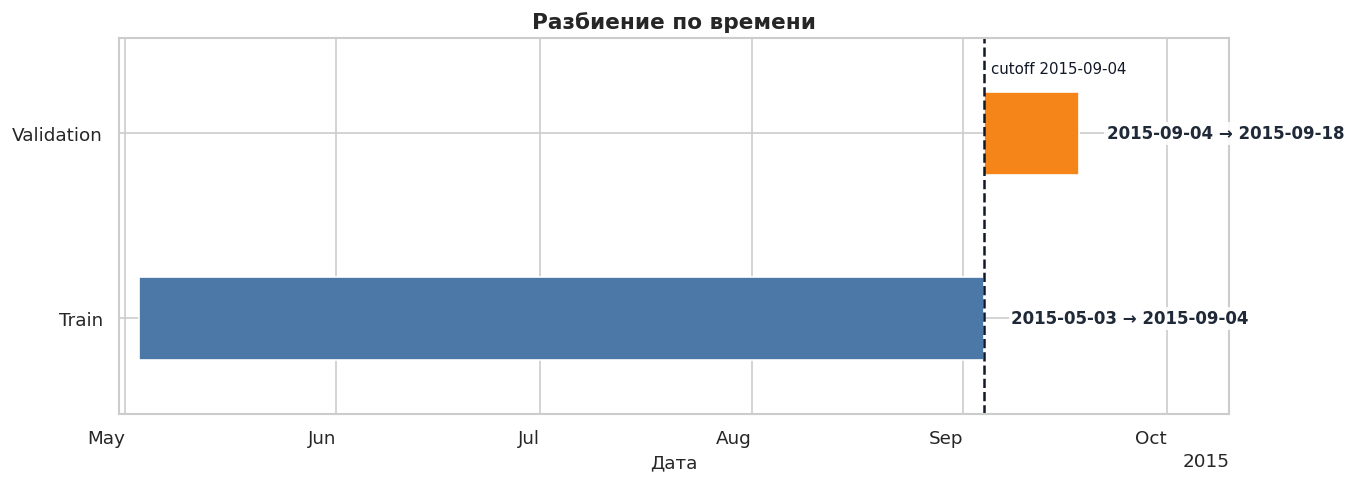

In [14]:
split_summary = pd.DataFrame([
    {'Окно': 'Train', 'Начало': modeling_report['split_summary']['train_start'], 'Конец': modeling_report['split_summary']['train_end'], 'Строк': modeling_report['split_summary']['train_rows']},
    {'Окно': 'Validation', 'Начало': modeling_report['split_summary']['validation_start'], 'Конец': modeling_report['split_summary']['validation_end'], 'Строк': modeling_report['split_summary']['validation_rows']},
])
split_summary['Начало'] = pd.to_datetime(split_summary['Начало'], format='mixed')
split_summary['Конец'] = pd.to_datetime(split_summary['Конец'], format='mixed')
split_summary['Дней'] = (split_summary['Конец'] - split_summary['Начало']).dt.days + 1

fig, ax = plt.subplots(figsize=(11.5, 4.2))
label_pad_days = 4
for idx, row in split_summary.iterrows():
    start_num = date2num(row['Начало'])
    end_num = date2num(row['Конец'])
    label = f"{row['Начало'].strftime('%Y-%m-%d')} → {row['Конец'].strftime('%Y-%m-%d')}"
    ax.barh(row['Окно'], end_num - start_num, left=start_num, color=['#4C78A8', '#F58518'][idx], height=0.45)
    ax.text(end_num + label_pad_days, idx, label, va='center', ha='left', color='#1F2937', fontweight='semibold', fontsize=10,
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.9, 'pad': 1.5})
cutoff_num = date2num(pd.to_datetime(modeling_report['split_summary']['cutoff_datetime']))
ax.axvline(cutoff_num, color='#111827', linestyle='--', linewidth=1.5)
ax.text(cutoff_num + 1, 1.35, pd.to_datetime(modeling_report['split_summary']['cutoff_datetime']).strftime('cutoff %Y-%m-%d'),
        color='#111827', fontsize=9, ha='left', va='center')
ax.set_title('Разбиение по времени')
ax.set_xlabel('Дата')
ax.set_ylabel('')
locator = mdates.AutoDateLocator(minticks=4, maxticks=7)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
xmin = date2num(split_summary['Начало'].min()) - 3
xmax = date2num(split_summary['Конец'].max()) + 22
ax.set_xlim(xmin, xmax)
ax.margins(y=0.2)
fig.autofmt_xdate(rotation=0)
plt.tight_layout()

split_display = split_summary.copy()
split_display['Начало'] = split_display['Начало'].dt.strftime('%Y-%m-%d')
split_display['Конец'] = split_display['Конец'].dt.strftime('%Y-%m-%d')
style_table(split_display, formats={'Строк': '{:,.0f}', 'Дней': '{:,.0f}'})


**Выводы блока**

- Train содержит 2,509,138 строк, validation — 246,963; cutoff приходится на 2015-09-04.
- Validation действительно находится на правом краю временной шкалы, а не внутри перемешанного пула событий.
- Такой split убирает temporal leakage и делает offline quality ближе к реальному serving-сценарию «прогноз на будущее окно».


## 3. Кого оценивает offline-контур

Eval cohort не является случайной выборкой по всем пользователям. В неё входят только пользователи с историей до cutoff и хотя бы одним будущим target item после исключения уже купленных товаров.


Интервал истории,Пользователи,Доля
1,167,32.81%
2-4,129,25.34%
5-9,72,14.15%
10-19,50,9.82%
20+,91,17.88%


Целевых товаров в validation-окне,Пользователи,Доля
1,357,70.14%
2,60,11.79%
3-5,57,11.20%
6-10,23,4.52%
10+,12,2.36%


Метрика,Значение
Пользователи в выборке оценки,509.00
Медиана событий в истории,3.00
Среднее число событий в истории,64.46
Медиана целевых товаров,1.00
Среднее число целевых товаров,2.54
Максимум целевых товаров,95.00


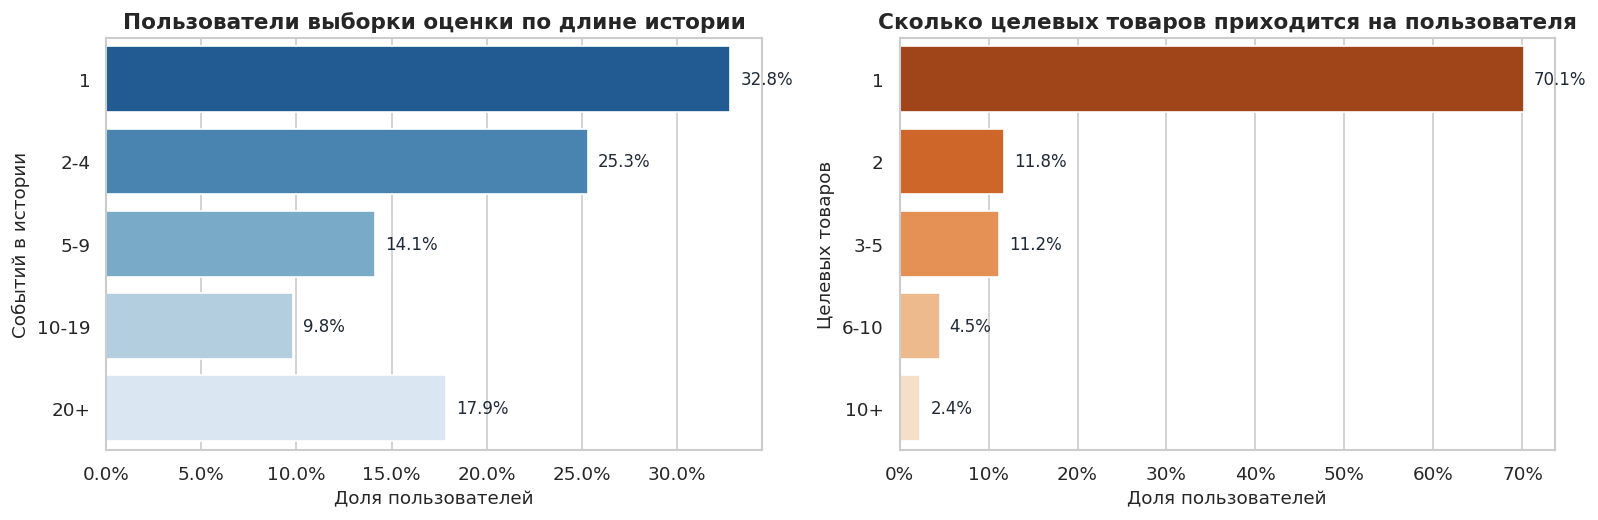

In [15]:
history_bucket = pd.DataFrame(modeling_report['history_bucket_distribution']).rename(columns={'history_bucket': 'Интервал истории', 'count': 'Пользователи', 'share': 'Доля'})
target_bucket = (
    eval_frame.assign(
        target_bucket=pd.cut(
            eval_frame['target_count'],
            bins=[0, 1, 2, 5, 10, 10**6],
            labels=['1', '2', '3-5', '6-10', '10+'],
            ordered=True,
        )
    )
    .groupby('target_bucket', observed=True)
    .size()
    .reset_index(name='Пользователи')
)
target_bucket['Доля'] = target_bucket['Пользователи'] / target_bucket['Пользователи'].sum()
target_bucket.rename(columns={'target_bucket': 'Целевых товаров в validation-окне'}, inplace=True)

cohort_summary = pd.DataFrame([
    {'Метрика': 'Пользователи в выборке оценки', 'Значение': len(eval_frame)},
    {'Метрика': 'Медиана событий в истории', 'Значение': eval_frame['history_events'].median()},
    {'Метрика': 'Среднее число событий в истории', 'Значение': eval_frame['history_events'].mean()},
    {'Метрика': 'Медиана целевых товаров', 'Значение': eval_frame['target_count'].median()},
    {'Метрика': 'Среднее число целевых товаров', 'Значение': eval_frame['target_count'].mean()},
    {'Метрика': 'Максимум целевых товаров', 'Значение': eval_frame['target_count'].max()},
])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))
sns.barplot(data=history_bucket, x='Доля', y='Интервал истории', hue='Интервал истории', dodge=False, legend=False, palette='Blues_r', ax=axes[0])
annotate_barh(axes[0], lambda value: fmt_pct(value * 100, 1))
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].set_title('Пользователи выборки оценки по длине истории')
axes[0].set_xlabel('Доля пользователей')
axes[0].set_ylabel('Событий в истории')

sns.barplot(data=target_bucket, x='Доля', y='Целевых товаров в validation-окне', hue='Целевых товаров в validation-окне', dodge=False, legend=False, palette='Oranges_r', ax=axes[1])
annotate_barh(axes[1], lambda value: fmt_pct(value * 100, 1))
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title('Сколько целевых товаров приходится на пользователя')
axes[1].set_xlabel('Доля пользователей')
axes[1].set_ylabel('Целевых товаров')
plt.tight_layout()

display(style_table(history_bucket, formats={'Пользователи': '{:,.0f}', 'Доля': '{:.2%}'}, gradient_subset=['Доля']))
display(style_table(target_bucket, formats={'Пользователи': '{:,.0f}', 'Доля': '{:.2%}'}, gradient_subset=['Доля']))
style_table(cohort_summary, formats={'Значение': '{:,.2f}'})


**Выводы блока**

- 32.81% eval users имеют ровно одно историческое событие, а 58.15% — не более четырёх событий.
- Медиана по числу target items равна 1, среднее — 2.54, поэтому большая часть пользователей имеет очень компактный future basket.
- Среднее число history events (64.46) заметно выше медианы из-за длинного хвоста, так что при проектировании сервиса нужно ориентироваться именно на короткую историю как на типовой сценарий.


## 4. Набор baseline-моделей

Сравнивались четыре модели. Каждая отвечает на отдельный инженерный вопрос: что даёт fallback без персонализации, насколько силён repeat-interest, нужен ли item-to-item retrieval и оправдывает ли себя гибридизация.


In [16]:
models = pd.DataFrame(modeling_report['model_definitions']).rename(columns={
    'model_name': 'Модель',
    'family': 'Класс модели',
    'why_included': 'Зачем добавлена',
})
models['Модель'] = models['Модель'].map(MODEL_LABELS)
style_table(models)


Модель,Класс модели,Зачем добавлена
Глобальная популярность,non-personalized baseline,нижняя граница качества и обязательный cold-start fallback
Исторический baseline,repeat-interest baseline,проверка гипотезы о силе короткой персональной истории в разреженном e-commerce
Взвешенный item2item,co-occurrence retrieval,"поиск новых, но похожих товаров без dense user-item матрицы"
Гибрид истории и item2item,history + retrieval,компромисс между повторным интересом и каталоговым расширением


**Выводы блока**

- `Global popularity` задаёт нижнюю границу качества и остаётся обязательным cold-start fallback.
- `History baseline` проверяет главную гипотезу проекта: может ли короткая личная история побить более сложный retrieval.
- `Weighted item2item` и `hybrid` важны не ради сложности как таковой, а ради измеримого trade-off между recall и расширением каталога.


## 5. Сравнение моделей по метрикам

Основной критерий выбора — `Recall@10`. Дополнительно анализируются `HitRate@10`, `NDCG@10` и `catalog coverage`, чтобы не потерять баланс между качеством попаданий и шириной выдачи.


Модель,Recall@10,HitRate@10,NDCG@10,Покрытие каталога,"Покрытие каталога, %",Δ Recall до лидера
Исторический baseline,0.1496,0.1906,0.1320,"1,794",0.763%,+0.0000
Гибрид истории и item2item,0.1377,0.1729,0.0838,"3,456",1.470%,-0.0118
Взвешенный item2item,0.0828,0.1120,0.0468,"3,310",1.408%,-0.0667
Глобальная популярность,0.0085,0.0216,0.0091,15,0.006%,-0.1411


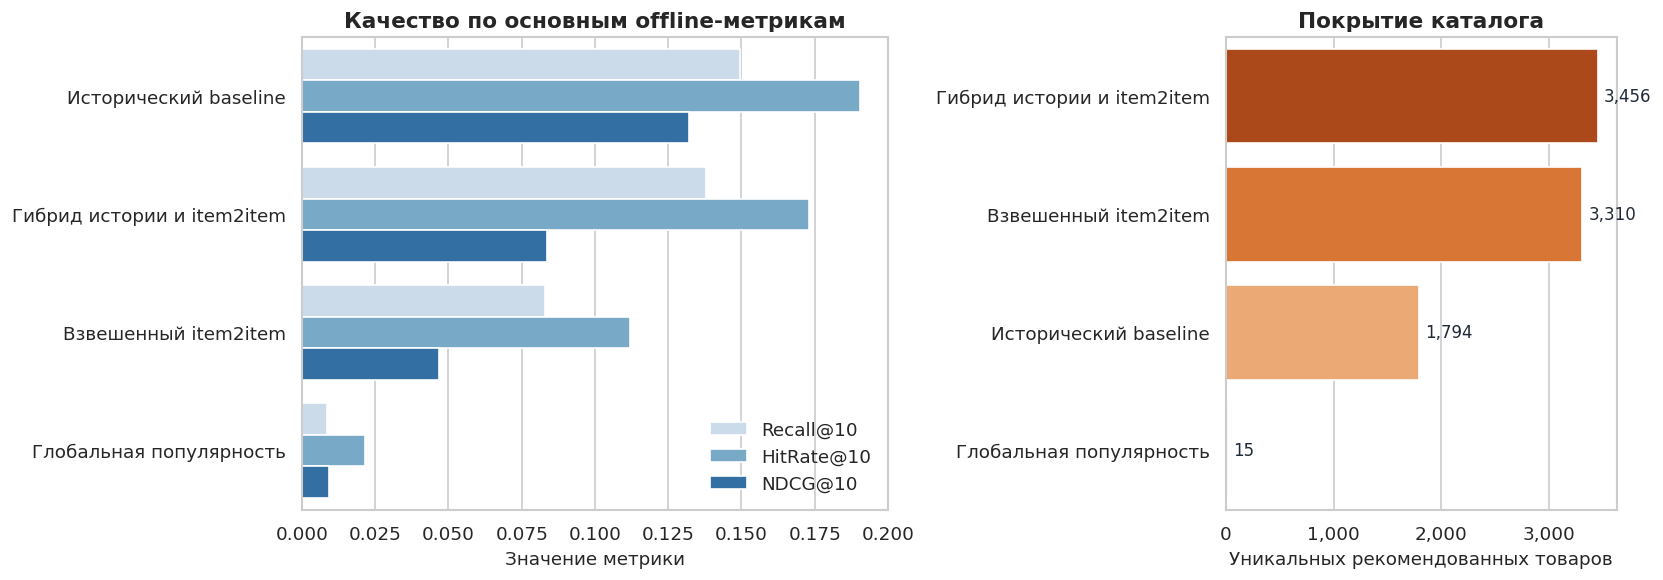

In [17]:
metrics = pd.DataFrame(modeling_report['metrics_table'])
best_recall = metrics['recall_at_k'].max()
metrics['Модель'] = metrics['model_name'].map(MODEL_LABELS)
metrics['Δ Recall до лидера'] = metrics['recall_at_k'] - best_recall
metrics = metrics.set_index('model_name').loc[MODEL_ORDER].reset_index()

metrics_display = metrics[['Модель', 'recall_at_k', 'hit_rate_at_k', 'ndcg_at_k', 'catalog_coverage', 'catalog_coverage_pct', 'Δ Recall до лидера']].rename(columns={
    'recall_at_k': 'Recall@10',
    'hit_rate_at_k': 'HitRate@10',
    'ndcg_at_k': 'NDCG@10',
    'catalog_coverage': 'Покрытие каталога',
    'catalog_coverage_pct': 'Покрытие каталога, %',
})

quality_long = metrics.melt(id_vars=['model_name', 'Модель'], value_vars=['recall_at_k', 'hit_rate_at_k', 'ndcg_at_k'], var_name='Метрика', value_name='Значение')
quality_long['Метрика'] = quality_long['Метрика'].map({'recall_at_k': 'Recall@10', 'hit_rate_at_k': 'HitRate@10', 'ndcg_at_k': 'NDCG@10'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.2, 0.8]})
sns.barplot(data=quality_long, x='Значение', y='Модель', hue='Метрика', palette='Blues', ax=axes[0])
axes[0].set_title('Качество по основным offline-метрикам')
axes[0].set_xlabel('Значение метрики')
axes[0].set_ylabel('')
axes[0].legend(title='')

coverage_plot = metrics[['Модель', 'catalog_coverage']].sort_values('catalog_coverage', ascending=False)
sns.barplot(data=coverage_plot, x='catalog_coverage', y='Модель', hue='Модель', dodge=False, legend=False, palette='Oranges_r', ax=axes[1])
annotate_barh(axes[1], lambda value: fmt_int(value))
axes[1].set_title('Покрытие каталога')
axes[1].set_xlabel('Уникальных рекомендованных товаров')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()

style_table(
    metrics_display,
    formats={
        'Recall@10': '{:.4f}',
        'HitRate@10': '{:.4f}',
        'NDCG@10': '{:.4f}',
        'Покрытие каталога': '{:,.0f}',
        'Покрытие каталога, %': '{:.3f}%',
        'Δ Recall до лидера': '{:+.4f}',
    },
    gradient_subset=['Recall@10', 'HitRate@10', 'NDCG@10'],
)


**Выводы блока**

- `History baseline` лидирует по всем основным quality-метрикам: `Recall@10 = 0.1496`, `HitRate@10 = 0.1906`, `NDCG@10 = 0.1320`.
- Ближайший конкурент — `Hybrid history + item2item` с `Recall@10 = 0.1377`, то есть на 0.0118 ниже лидера.
- `Weighted item2item` расширяет каталог до 3,310 товаров, но по recall (0.0828) заметно проигрывает history-based ранжированию.


## 6. Почему победил `history_baseline`

Общая таблица метрик важна, но недостаточна. Чтобы выбор финальной модели выглядел осознанным, нужно проверить качество по сегментам длины истории.


Интервал истории,Recall@10 history baseline,Recall@10 гибрида,Δ history - hybrid
1,0.1128,0.1277,-0.0149
10-19,0.2406,0.1772,+0.0634
2-4,0.1589,0.1647,-0.0058
20+,0.1244,0.0875,+0.0369
5-9,0.1868,0.1486,+0.0382


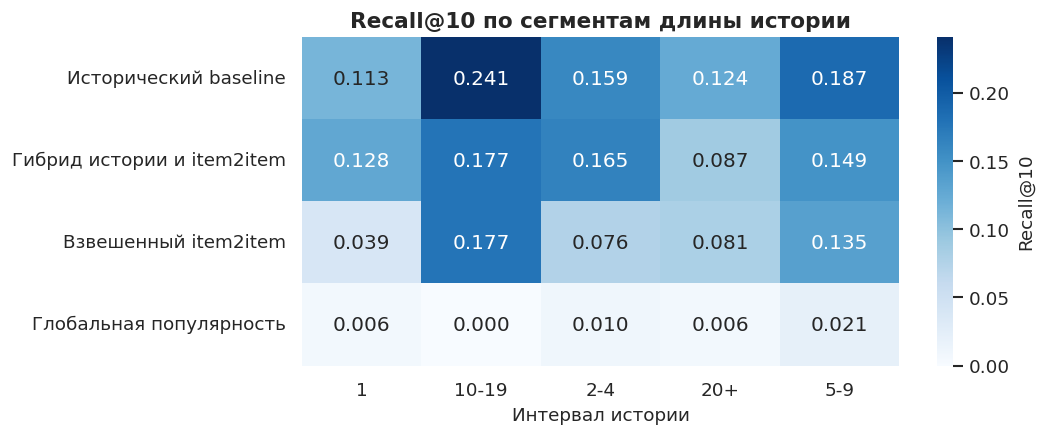

In [18]:
bucket_metrics = pd.DataFrame(modeling_report['history_bucket_metrics'])
heatmap_data = (
    bucket_metrics
    .pivot(index='model_name', columns='history_bucket', values='recall_at_k')
    .loc[MODEL_ORDER]
    .rename(index=MODEL_LABELS)
)
history_vs_hybrid = pd.DataFrame({
    'Интервал истории': heatmap_data.columns,
    'Recall@10 history baseline': heatmap_data.loc['Исторический baseline'].values,
    'Recall@10 гибрида': heatmap_data.loc['Гибрид истории и item2item'].values,
})
history_vs_hybrid['Δ history - hybrid'] = history_vs_hybrid['Recall@10 history baseline'] - history_vs_hybrid['Recall@10 гибрида']

fig, ax = plt.subplots(figsize=(9, 3.8))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='Blues', cbar_kws={'label': 'Recall@10'}, ax=ax)
ax.set_title('Recall@10 по сегментам длины истории')
ax.set_xlabel('Интервал истории')
ax.set_ylabel('')
plt.tight_layout()

style_table(history_vs_hybrid, formats={
    'Recall@10 history baseline': '{:.4f}',
    'Recall@10 гибрида': '{:.4f}',
    'Δ history - hybrid': '{:+.4f}',
}, gradient_subset=['Δ history - hybrid'])


**Выводы блока**

- На самых коротких историях hybrid немного сильнее: в bucket `1` его `Recall@10 = 0.1277` против 0.1128 у history baseline.
- Начиная с более содержательной истории история побеждает: в bucket `5-9` `History baseline` даёт 0.1868 против 0.1486, а в `10-19` — 0.2406 против 0.1772.
- Именно эти более уверенные выигрыши на насыщенных профилях и дают итоговое лидерство по общему recall без усложнения serving-логики.


## 7. Trade-off: recall против catalog coverage

Более сложная модель оправдана только тогда, когда прирост каталоговой широты превращается в реальный выигрыш по основной метрике. Здесь это соотношение видно напрямую.


Модель,Recall@10,Покрытие каталога,"Покрытие каталога, %"
Исторический baseline,0.1496,"1,794",0.763%
Гибрид истории и item2item,0.1377,"3,456",1.470%
Взвешенный item2item,0.0828,"3,310",1.408%
Глобальная популярность,0.0085,15,0.006%


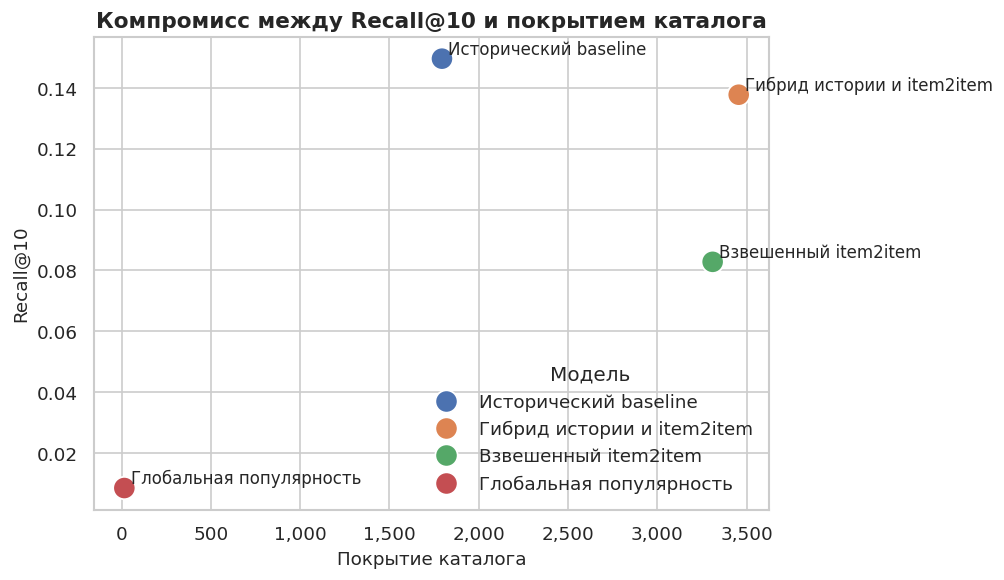

In [19]:
tradeoff = metrics[['Модель', 'recall_at_k', 'catalog_coverage', 'catalog_coverage_pct']].copy()

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.scatterplot(data=tradeoff, x='catalog_coverage', y='recall_at_k', hue='Модель', s=180, palette='deep', ax=ax)
for _, row in tradeoff.iterrows():
    ax.text(row['catalog_coverage'] + 35, row['recall_at_k'] + 0.0015, row['Модель'], fontsize=10)
ax.set_title('Компромисс между Recall@10 и покрытием каталога')
ax.set_xlabel('Покрытие каталога')
ax.set_ylabel('Recall@10')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()

style_table(tradeoff.rename(columns={
    'recall_at_k': 'Recall@10',
    'catalog_coverage': 'Покрытие каталога',
    'catalog_coverage_pct': 'Покрытие каталога, %',
}), formats={'Recall@10': '{:.4f}', 'Покрытие каталога': '{:,.0f}', 'Покрытие каталога, %': '{:.3f}%'})


**Выводы блока**

- `Hybrid` расширяет каталог до 3,456 товаров против 1,794 у history baseline, то есть почти в 1.93 раза.
- Однако этот выигрыш по coverage сопровождается падением `Recall@10` с 0.1496 до 0.1377.
- Для текущего проекта это означает, что discovery-расширение пока не окупает потери по основной offline-метрике и усложнение ранжирования.


## 8. Cold-start, short history и serving stability

Победа `history_baseline` не означает, что сервис может жить без fallback. Нужно отдельно проверить, насколько плотны user profiles и как часто будущий target вообще повторяет уже увиденное.


Сегмент,Доля,Количество
Train users с ≥2 уникальными товарами,20.37%,"260,764"
Пользователи выборки оценки с ≥2 уникальными товарами,60.31%,307
Пользователи выборки оценки с любым повтором целевого товара из истории,18.86%,96
"Пользователи выборки оценки, у которых весь целевой набор уже был в истории",12.57%,64


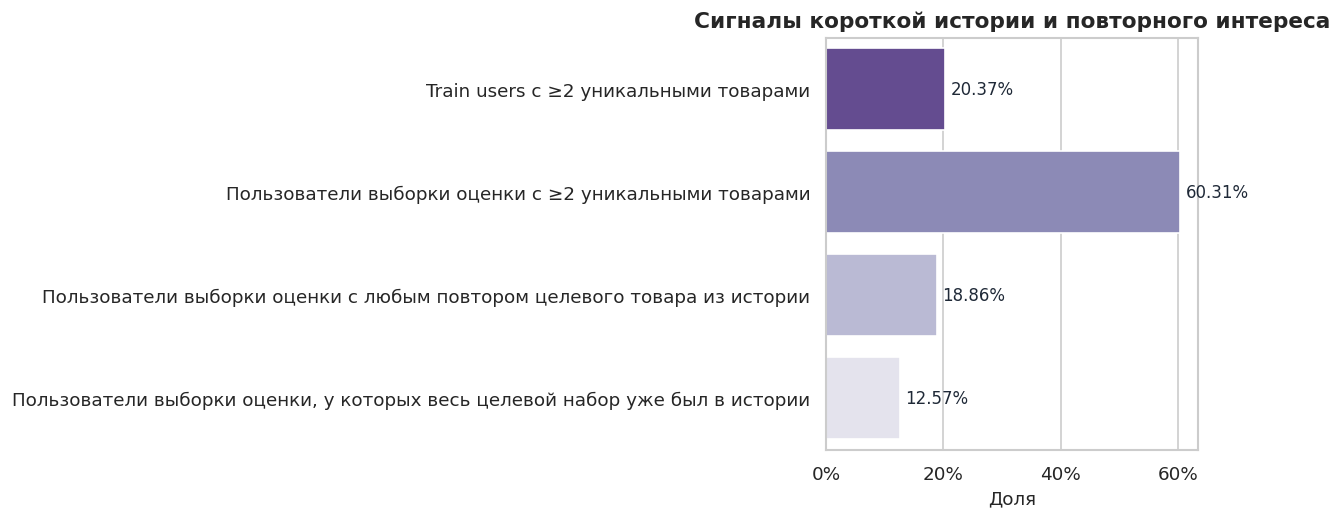

In [20]:
serving_profile = pd.DataFrame([
    {'Сегмент': 'Train users с ≥2 уникальными товарами', 'Доля': modeling_report['serving_profile_eligibility']['train_users_with_2plus_items_share'], 'Количество': modeling_report['serving_profile_eligibility']['train_users_with_2plus_items']},
    {'Сегмент': 'Пользователи выборки оценки с ≥2 уникальными товарами', 'Доля': modeling_report['serving_profile_eligibility']['eval_users_with_2plus_items_share'], 'Количество': modeling_report['serving_profile_eligibility']['eval_users_with_2plus_items']},
    {'Сегмент': 'Пользователи выборки оценки с любым повтором целевого товара из истории', 'Доля': modeling_report['evaluation_dataset']['share_with_repeat_target_from_history'], 'Количество': modeling_report['evaluation_dataset']['share_with_repeat_target_from_history'] * modeling_report['evaluation_dataset']['users']},
    {'Сегмент': 'Пользователи выборки оценки, у которых весь целевой набор уже был в истории', 'Доля': modeling_report['evaluation_dataset']['share_with_full_target_in_history'], 'Количество': modeling_report['evaluation_dataset']['share_with_full_target_in_history'] * modeling_report['evaluation_dataset']['users']},
])

fig, ax = plt.subplots(figsize=(10.5, 4.5))
sns.barplot(data=serving_profile, x='Доля', y='Сегмент', hue='Сегмент', dodge=False, legend=False, palette='Purples_r', ax=ax)
annotate_barh(ax, lambda value: fmt_pct(value * 100, 2))
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title('Сигналы короткой истории и повторного интереса')
ax.set_xlabel('Доля')
ax.set_ylabel('')
plt.tight_layout()

style_table(serving_profile, formats={'Доля': '{:.2%}', 'Количество': '{:,.0f}'}, gradient_subset=['Доля'])


**Выводы блока**

- В train только 20.37% пользователей имеют минимум два уникальных item-а, поэтому popularity fallback обязателен уже на уровне serving store.
- Даже в eval cohort лишь 18.86% пользователей имеют хотя бы часть будущего target в истории и только 12.57% — полный target.
- Это объясняет одновременно силу history-модели и её предел: repeat-interest хорошо работает там, где он есть, но cold-start и genuine discovery остаются отдельной operational задачей.


## 9. Качественные примеры рекомендаций

Сырые списки item-id полезны только тогда, когда они собраны в компактные сценарии. Ниже показаны пять типовых кейсов, которые объясняют поведение победителя и его ограничений.


In [21]:
samples = pd.DataFrame(modeling_report['sample_cases'])
case_labels = {
    'repeat_short_history_hit': 'Короткая история: повторный hit',
    'repeat_medium_history_hit': 'Средняя история: повторный hit',
    'item2item_recovers_new_item': 'Item2item находит новый релевантный товар',
    'history_beats_hybrid_on_repeat_interest': 'History выигрывает у hybrid на повторном интересе',
    'difficult_multi_target_miss': 'Сложный промах по нескольким целевым товарам',
}
case_notes = {
    'repeat_short_history_hit': 'History baseline получает recall 1.0, имея всего один ранее просмотренный товар.',
    'repeat_medium_history_hit': 'History baseline и item2item одинаково хорошо восстанавливают компактную повторную корзину.',
    'item2item_recovers_new_item': 'Item2item поднимает новый релевантный товар, который history-модель не может повторить напрямую.',
    'history_beats_hybrid_on_repeat_interest': 'Дополнительные соседи вытесняют повторный товар и ухудшают hybrid-ранжирование.',
    'difficult_multi_target_miss': 'Ни одна модель не попадает, когда будущая корзина полностью уходит от наблюдаемой истории.',
}
samples['Сценарий'] = samples['case_label'].map(case_labels)
samples['История'] = samples['history_items'].map(lambda x: shorten_items(x, limit=4))
samples['Факт'] = samples['actual'].map(lambda x: shorten_items(x, limit=4))
samples['Recall history@10'] = samples['history_recall_at_k']
samples['Recall item2item@10'] = samples['weighted_recall_at_k']
samples['Recall hybrid@10'] = samples['hybrid_recall_at_k']
samples['Интерпретация'] = samples['case_label'].map(case_notes)

samples_display = samples[['Сценарий', 'history_events', 'История', 'Факт', 'Recall history@10', 'Recall item2item@10', 'Recall hybrid@10', 'Интерпретация']].rename(columns={'history_events': 'Событий в истории'})
style_table(samples_display, formats={'Recall history@10': '{:.1f}', 'Recall item2item@10': '{:.1f}', 'Recall hybrid@10': '{:.1f}'})


Сценарий,Событий в истории,История,Факт,Recall history@10,Recall item2item@10,Recall hybrid@10,Интерпретация
Короткая история: повторный hit,1,386324,386324,1.0,0.0,1.0,"History baseline получает recall 1.0, имея всего один ранее просмотренный товар."
Средняя история: повторный hit,7,"79056, 264689, 170943","79056, 264689",1.0,1.0,1.0,History baseline и item2item одинаково хорошо восстанавливают компактную повторную корзину.
Item2item находит новый релевантный товар,1,303978,436412,0.0,1.0,1.0,"Item2item поднимает новый релевантный товар, который history-модель не может повторить напрямую."
History выигрывает у hybrid на повторном интересе,1,450760,450760,1.0,0.0,0.0,Дополнительные соседи вытесняют повторный товар и ухудшают hybrid-ранжирование.
Сложный промах по нескольким целевым товарам,1,405507,"35221, 140201, 304979",0.0,0.0,0.0,"Ни одна модель не попадает, когда будущая корзина полностью уходит от наблюдаемой истории."


**Интерпретация примеров**

- В кейсе `Short history repeat hit` history baseline получает `Recall@10 = 1.0` уже при одной исторической позиции, тогда как `weighted_item2item` остаётся на 0.0.
- В сценарии `Item2item recovers unseen item` retrieval полезен: history baseline даёт 0.0, а item2item и hybrid — по 1.0.
- В кейсе `History beats hybrid on repeat signal` добавление соседей ухудшает ranking: history baseline сохраняет `Recall@10 = 1.0`, а hybrid падает до 0.0.


## 10. Итоговый выбор модели

Финальная модель проекта — `history_baseline`.

Основания выбора:

1. Лучшая offline quality: `Recall@10 = 0.1496`, `HitRate@10 = 0.1906`, `NDCG@10 = 0.1320`.
2. Осознанный выбор по trade-off: hybrid почти удваивает catalog coverage (3,456 против 1,794), но всё равно уступает по recall.
3. Простая serving-логика: repeat-interest ранжирование естественно сочетается с popularity fallback, который нужен из-за того, что только 20.37% train users имеют хотя бы два уникальных item-а.
4. Более сложные модели не отвергаются как бесполезные: они показали ценность в retrieval-кейсах, но на текущем датасете не оправдали переход по сложности в финальный production artifact.
